In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [53]:

plt.rcParams["text.usetex"] = True
plt.rcParams['font.size'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 17
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.fontsize'] = 16

# Linien und Marker
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['lines.markersize'] = 8
plt.rcParams['errorbar.capsize'] = 5

# DPI und Qualität
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['figure.constrained_layout.use'] = True

# Achsen-Styling
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['xtick.major.width'] = 1.2
plt.rcParams['ytick.major.width'] = 1.2
plt.rcParams['xtick.major.size'] = 6
plt.rcParams['ytick.major.size'] = 6


In [6]:
df = pd.read_excel("data/RAD-Cosmic.xlsx", sheet_name="data")

In [7]:
df.head()

,Kanal,Anzahl_Co60,Anzahl_messung
0,0,0,0
1,1,0,0
2,2,0,0
3,3,0,1
4,4,0,0


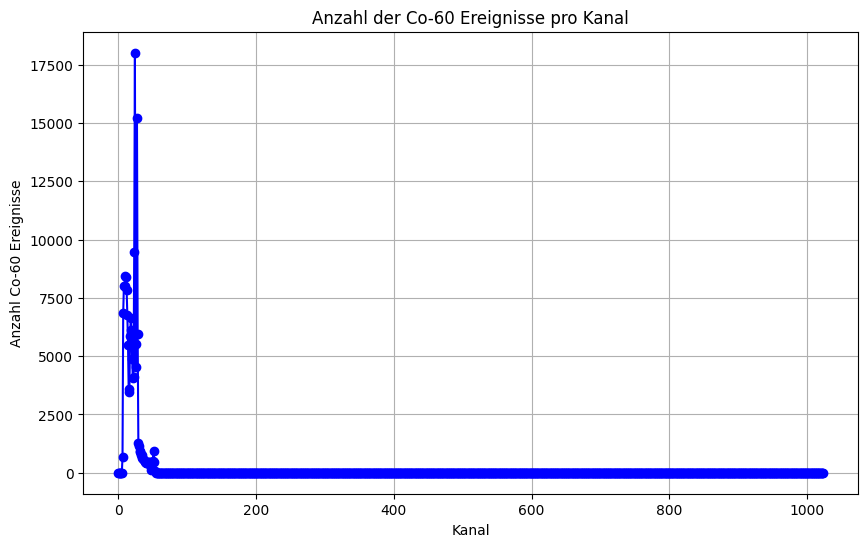

In [8]:
# plot Kanal on x-axis and Anzahl_Co60 on y-axis
plt.figure(figsize=(10, 6))
plt.plot(df["Kanal"], df["Anzahl_Co60"], marker='o', linestyle='-', color='blue')
plt.title("Anzahl der Co-60 Ereignisse pro Kanal")
plt.xlabel("Kanal")
plt.ylabel("Anzahl Co-60 Ereignisse")
plt.grid(True)
plt.show()

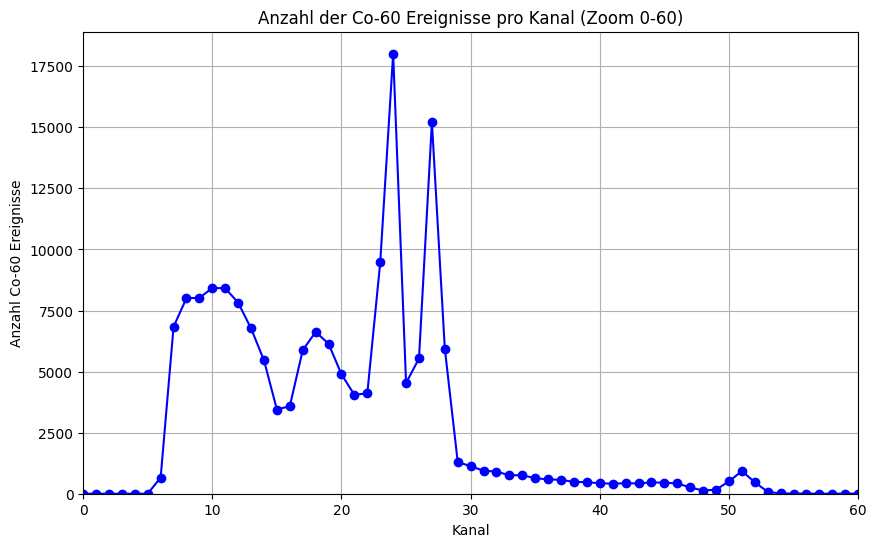

Index(['Kanal', 'Anzahl_Co60', 'Anzahl_messung'], dtype='object')


In [45]:
# Adjustable plot
x_min = 0
x_max = 60

# Filter data for y-axis scaling
mask = (df["Kanal"] >= x_min) & (df["Kanal"] <= x_max)
y_max = df.loc[mask, "Anzahl_Co60"].max()
y_limit = y_max * 1.05 if pd.notna(y_max) else None # Add 5% padding

plt.figure(figsize=(10, 6))
plt.plot(df["Kanal"], df["Anzahl_Co60"], marker='o', linestyle='-', color='blue')

plt.xlim(x_min, x_max)
if y_limit:
    plt.ylim(0, y_limit)

plt.title(f"Anzahl der Co-60 Ereignisse pro Kanal (Zoom {x_min}-{x_max})")
plt.xlabel("Kanal")
plt.ylabel("Anzahl Co-60 Ereignisse")
plt.grid(True)
plt.show()

print(df.columns)

In [70]:
# Find peaks manually in specified regions
def find_peak(df, start_ch, end_ch):
    subset = df[(df["Kanal"] >= start_ch) & (df["Kanal"] <= end_ch)]
    max_idx = subset["Anzahl_Co60"].idxmax()
    peak_row = subset.loc[max_idx]
    return peak_row["Kanal"], peak_row["Anzahl_Co60"]

# Range 1: 20-26
p1_ch, p1_counts = find_peak(df, 20, 26)
print(f"Peak 1 (Range 20-26): Channel {p1_ch}, Counts {p1_counts}")

# Range 2: 26-30 (Around 27)
p2_ch, p2_counts = find_peak(df, 26, 30)
print(f"Peak 2 (Range 26-30): Channel {p2_ch}, Counts {p2_counts}")

# Range 3: 50-55
p3_ch, p3_counts = find_peak(df, 48, 56)
print(f"Peak 3 (Range 48-56): Channel {p3_ch}, Counts {p3_counts}")

Peak 1 (Range 20-26): Channel 24, Counts 18011
Peak 2 (Range 26-30): Channel 27, Counts 15209
Peak 3 (Range 48-56): Channel 51, Counts 926


In [71]:
data = pd.DataFrame({
    "Peak": ["Peak 1", "Peak 2", "Peak 3"],
    "Kanäle": [24, 27, 51],
    "Energie in keV": [1173, 1333, 2506]
})

In [74]:
# plot Kanäle x and counts y for the peaks and do a linear fit a*c + b
from scipy.optimize import curve_fit
from uncertainties import ufloat
from uncertainties import unumpy as unp
import numpy as np

def linear_model(x, a, b):
    return a * x + b

popt, pcov = curve_fit(linear_model, data["Kanäle"], data["Energie in keV"])
perr = np.sqrt(np.diag(pcov))

a_u = ufloat(popt[0], perr[0])
b_u = ufloat(popt[1], perr[1])

print(f"Fitted parameters:")
print(f"a = {a_u:.2u}")
print(f"b = {b_u:.2u}")

Fitted parameters:
a = 49.18+/-0.42
b = -1+/-15


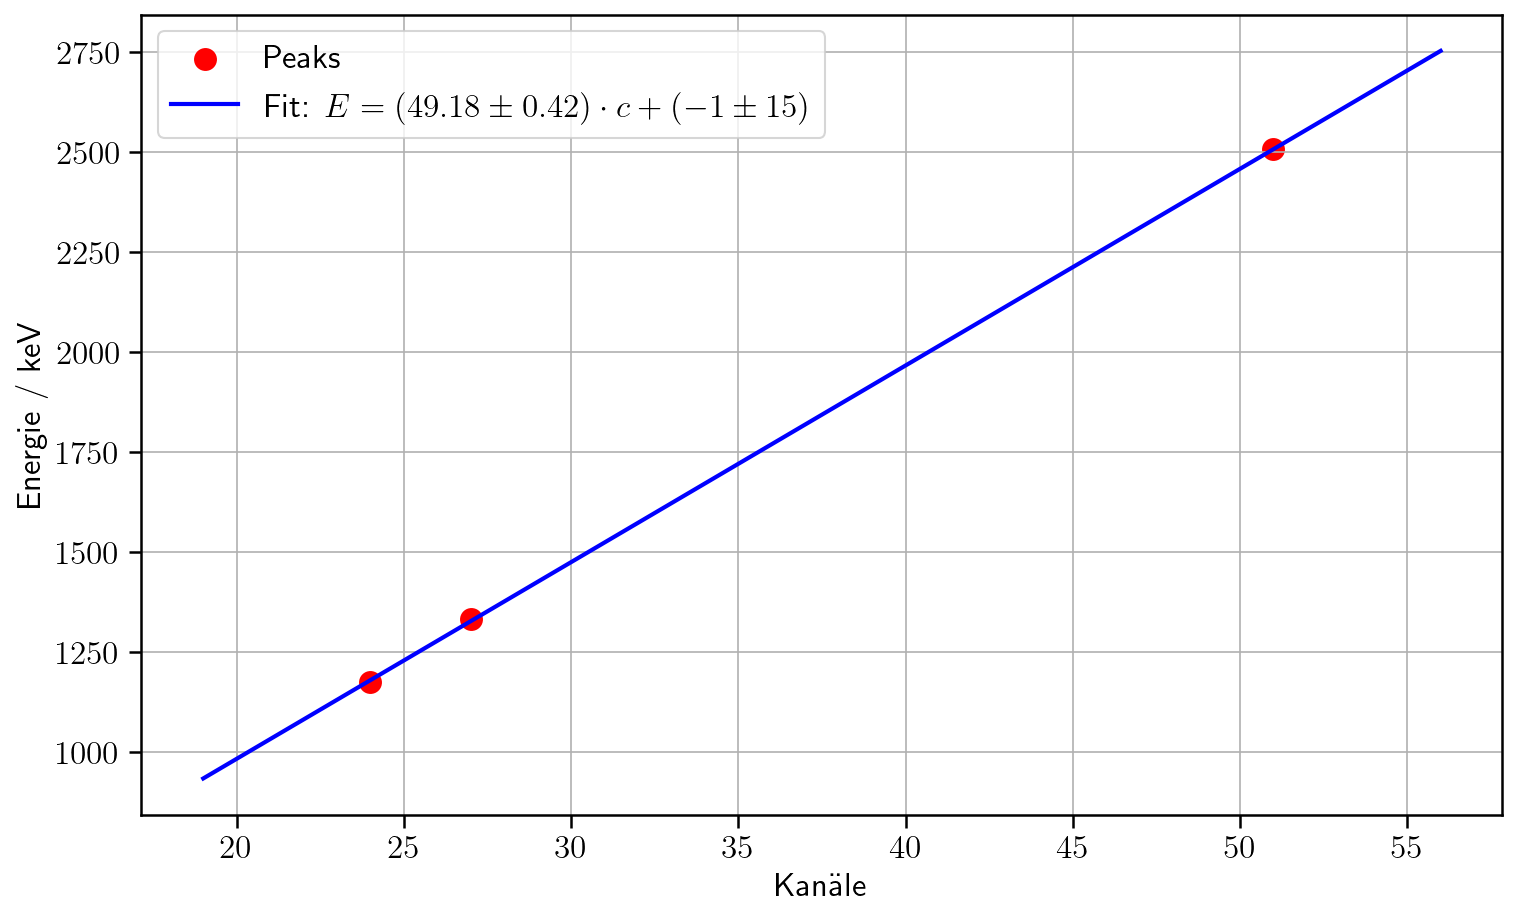

In [75]:



# plot the peaks and the fit
plt.figure(figsize=(10, 6))
plt.scatter(data["Kanäle"], data["Energie in keV"], color='red', label='Peaks', s=100)
x_fit = np.linspace(min(data["Kanäle"]) - 5, max(data["Kanäle"]) + 5, 100)
y_fit = linear_model(x_fit, a_u.n, b_u.n)
plt.plot(x_fit, y_fit, color='blue', label=f'Fit: $E = ({a_u:.2uL}) \\cdot c + ({b_u:.2uL})$')
plt.xlabel("Kanäle")
plt.ylabel("Energie / keV")
plt.xlabel("Kanäle")
plt.ylabel("Energie / keV")
plt.legend()
plt.grid(True)
# save as svg
plt.savefig("RAD_Co60_calibration.svg", format='svg', bbox_inches='tight')

In [ ]:
"""Lesen Sie die
Inhalte der Kanäle 100- 199, 200-299,....,900-999 aus. Die Kanäle 1-99 interessieren bei der Messung
der Höhenstrahlung nicht, da hier im wesentlichen die Strahlung radioaktiver Nuklide registriert wird."""
data = pd.read_excel("data/RAD-Cosmic.xlsx", sheet_name="data")
# colum Anzahl_messung
channel_ranges = [(100, 199), (200, 299), (300, 399), (400, 499), (500, 599), (600, 699), (700, 799), (800, 899), (900, 999)]

# make a separate plot for each range
for start, end in channel_ranges:
    subset = data[(data["Kanal"] >= start) & (data["Kanal"] <= end)]
    plt.figure(figsize=(10, 6))
    plt.plot(subset["Kanal"], subset["Anzahl_messung"], marker='o', linestyle='-', color='green')
    plt.title(f"Anzahl der Messungen pro Kanal (Range {start}-{end})")
    plt.xlabel("Kanal")
    plt.ylabel("Anzahl der Messungen")
    plt.grid(True)
    plt.show()


In [ ]:
# plot the whole data set with Anzahl_messung on y-axis and Kanal on x-axis
plt.figure(figsize=(10, 6))
plt.plot(data["Kanal"], data["Anzahl_messung"], marker='o', linestyle='-', color='purple')
plt.title("Anzahl der Messungen pro Kanal")
plt.xlabel("Kanal")
plt.ylabel("Anzahl der Messungen")
plt.grid(True)
plt.show()

In [77]:
# --- Aufgabe 6: Auswertung Höhenstrahlung ---
print("-" * 50)
print("AUSWERTUNG HÖHENSTRAHLUNG")
print("-" * 50)

# 1. Parameter
# Energie-Eichung: E(c) = m*c + b
# Verwende Ergebnisse aus Fit (mit Unsicherheit)
m_cal = a_u
b_cal = b_u
print(f"Verwendete Eichung: m = {m_cal:.2u}, b = {b_cal:.2u}")

def get_energy_kev(channel):
    return m_cal * channel + b_cal

# 2. Messdaten & Bins
# Bins: 100-199, 200-299, ..., 900-999
bin_ranges = [
    (100, 199), (200, 299), (300, 399), (400, 499),
    (500, 599), (600, 699), (700, 799), (800, 899), (900, 999)
]

# Automatische Extraktion der Counts aus dem DataFrame 'data'
counts = {}
print("Counts pro Bereich (aus Datei extrahiert):")
for start, end in bin_ranges:
    # Summiere 'Anzahl_messung' für den Bereich
    mask = (data["Kanal"] >= start) & (data["Kanal"] <= end)
    # Verwende Unsicherheiten für die Zählrate (Poisson)
    count_val = data.loc[mask, "Anzahl_messung"].sum()
    counts[f"{start}-{end}"] = ufloat(count_val, np.sqrt(count_val))
    print(f"  Bin {start}-{end}: {counts[f'{start}-{end}']:.2u} Ereignisse")

# 3. Berechnung der Gesamtenergie der Messung
# Methode: Mittelwert des Bins nutzen
total_energy_meas_kev = 0

print("\nBerechnung Energie pro Bin:")
for bin_name, count in counts.items():
    start, end = map(int, bin_name.split('-'))
    midpoint = (start + end) / 2

    energy_per_event_kev = get_energy_kev(midpoint)
    energy_bin_total_kev = count * energy_per_event_kev

    total_energy_meas_kev += energy_bin_total_kev

print(f"\nGesamtenergie (2h Messung): {total_energy_meas_kev:.2u} keV")

# 4. Zeitliche Skalierung
duration_hours = 2.0
year_hours = 365.25 * 24.0

scale_factor = year_hours / duration_hours
total_energy_year_kev = total_energy_meas_kev * scale_factor

print(f"Zeit-Skalierungsfaktor (2h -> 1 Jahr): {scale_factor:.2f}")
print(f"Gesamtenergie (1 Jahr): {total_energy_year_kev:.2u} keV")

# 5. Dosis-Berechnung
# Konstanten
ev_to_joule = 1.602e-19
kev_to_joule = 1e3 * ev_to_joule

# Energie in Joule
total_energy_year_joule = total_energy_year_kev * kev_to_joule
print(f"Gesamtenergie (1 Jahr) in Joule: {total_energy_year_joule:.2u} J")

# Massen und Dosis
m_detektor = 1.0 # kg (anpassbar)
quality_factor_wR = 1 # für Myonen/Elektronen

# Energiedosis D = E / m
dose_gray = total_energy_year_joule / m_detektor # Gy = J/kg

# Äquivalentdosis H = D * w_R
dose_sievert = dose_gray * quality_factor_wR

print("-" * 30)
print(f"Parameter: Detektormasse = {m_detektor} kg, w_R = {quality_factor_wR}")
print(f"Jährliche Energiedosis D = {dose_gray:.2u} Gy/a")
print(f"Jährliche Äquivalentdosis H = {(dose_sievert * 1000):.2u} mSv/a")
print("-" * 30)


--------------------------------------------------
AUSWERTUNG HÖHENSTRAHLUNG
--------------------------------------------------
Verwendete Eichung: m = 49.18+/-0.42, b = -1+/-15
Counts pro Bereich (aus Datei extrahiert):
  Bin 100-199: 1687+/-41 Ereignisse
  Bin 200-299: 1235+/-35 Ereignisse
  Bin 300-399: 1099+/-33 Ereignisse
  Bin 400-499: 1033+/-32 Ereignisse
  Bin 500-599: 1055+/-32 Ereignisse
  Bin 600-699: 1356+/-37 Ereignisse
  Bin 700-799: 1149+/-34 Ereignisse
  Bin 800-899: 590+/-24 Ereignisse
  Bin 900-999: 274+/-17 Ereignisse

Berechnung Energie pro Bin:

Gesamtenergie (2h Messung): (2.209+/-0.032)e+08 keV
Zeit-Skalierungsfaktor (2h -> 1 Jahr): 4383.00
Gesamtenergie (1 Jahr): (9.68+/-0.14)e+11 keV
Gesamtenergie (1 Jahr) in Joule: 0.0001551+/-0.0000022 J
------------------------------
Parameter: Detektormasse = 1.0 kg, w_R = 1
Jährliche Energiedosis D = 0.0001551+/-0.0000022 Gy/a
Jährliche Äquivalentdosis H = 0.1551+/-0.0022 mSv/a
------------------------------
